In [1]:
import pandas as pd
import numpy as np
import shap
import lime
import lime.lime_text
import random
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

c:\Users\Jai Mata di\Downloads\Phishing Website Detection Dataset\Phishing Website Detection Dataset\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_path = r"C:\Users\Jai Mata di\Downloads\Phishing Website Detection Dataset\Phishing Website Detection Dataset\Data\Train"

with open(os.path.join(train_path, "benign_Train.txt"), "r", encoding="latin1") as f:
    benign_urls = f.read().splitlines()

with open(os.path.join(train_path, "malign_Train.txt"), "r", encoding="latin1") as f:
    phishing_urls = f.read().splitlines()

print("Benign:", len(benign_urls))
print("Phishing:", len(phishing_urls))

Benign: 2000000
Phishing: 2000000


In [3]:
benign_df = pd.DataFrame({"url": benign_urls, "label": 0})
phishing_df = pd.DataFrame({"url": phishing_urls, "label": 1})

df = pd.concat([benign_df, phishing_df], ignore_index=True)

print("Total dataset:", df.shape)

Total dataset: (4000000, 2)


In [4]:
X = df["url"]
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train:", len(X_train_text))
print("Test:", len(X_test_text))

Train: 2800000
Test: 1200000


In [5]:
vectorizer = TfidfVectorizer(max_features=30000)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("TF-IDF Train Shape:", X_train.shape)

TF-IDF Train Shape: (2800000, 30000)


In [6]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Accuracy: 0.898645

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.87      0.90    600000
           1       0.88      0.92      0.90    600000

    accuracy                           0.90   1200000
   macro avg       0.90      0.90      0.90   1200000
weighted avg       0.90      0.90      0.90   1200000

Confusion Matrix:
 [[524348  75652]
 [ 45974 554026]]


In [9]:
import joblib

joblib.dump(model, "xgb_phishing_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and Vectorizer saved ✅")

Model and Vectorizer saved ✅


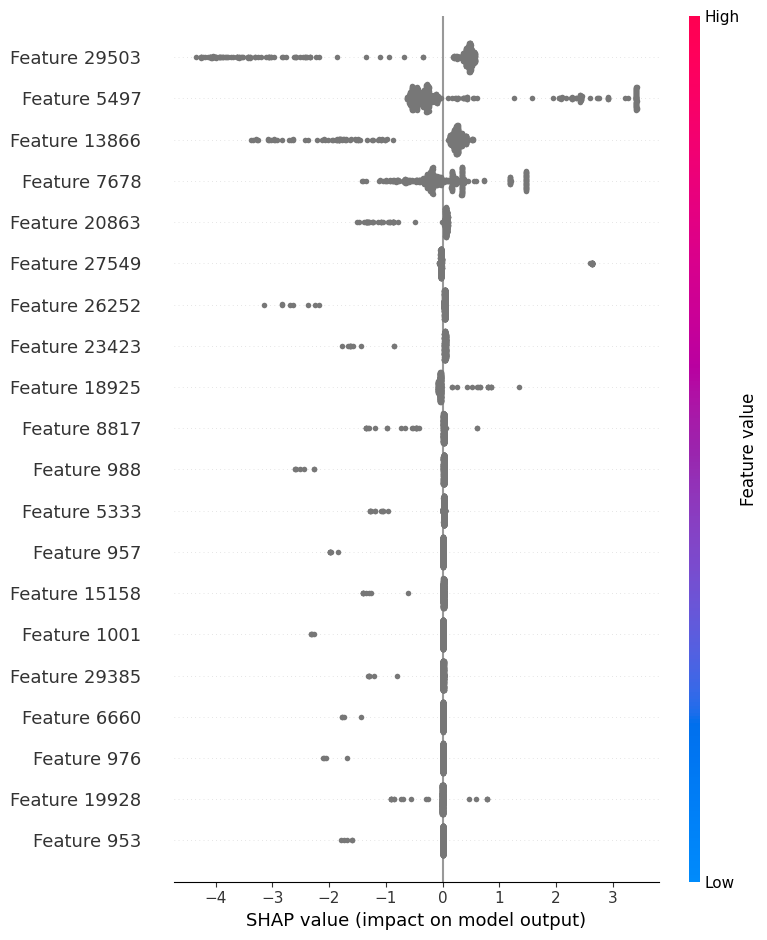

In [10]:
import shap

# small sample only
X_sample = X_train[:500]

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample, check_additivity=False)

shap.summary_plot(shap_values, X_sample)

In [12]:
import lime
import lime.lime_text
import random

explainer_lime = lime.lime_text.LimeTextExplainer(
    class_names=["Benign", "Phishing"]
)

# Random sample
i = random.randint(0, len(X_test_text)-1)
sample_text = X_test_text.iloc[i]

print("Explaining URL:\n", sample_text)

exp = explainer_lime.explain_instance(
    sample_text,
    lambda x: model.predict_proba(vectorizer.transform(x)),
    num_features=10
)

# Save explanation to HTML file
exp.save_to_file("lime_explanation.html")

print("LIME explanation saved as lime_explanation.html ✅")

Explaining URL:
 www.imc-gd.ru/np/mto/
LIME explanation saved as lime_explanation.html ✅


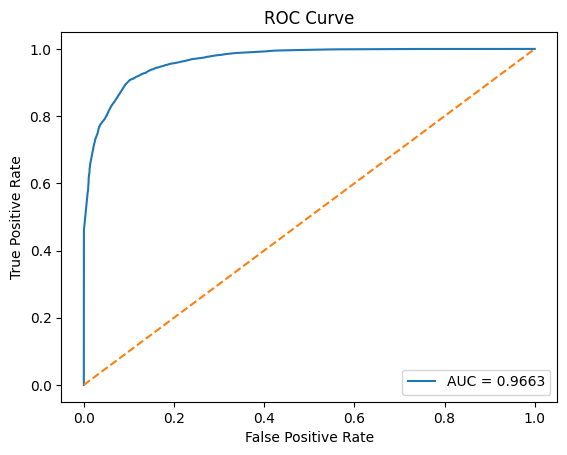

In [14]:
from sklearn.metrics import roc_curve, auc

# Predict probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label="AUC = %0.4f" % roc_auc)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

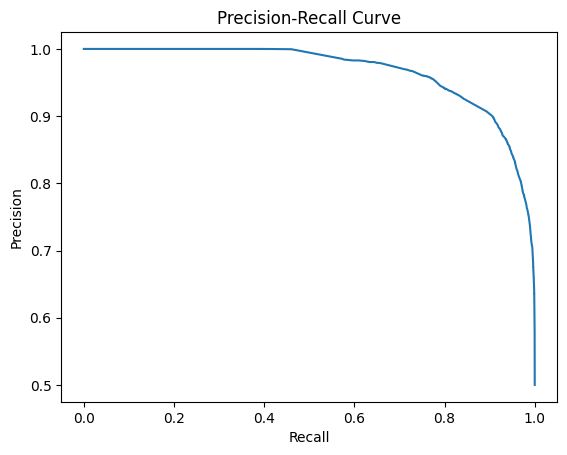

In [15]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [16]:
def predict_url(url):
    url_vector = vectorizer.transform([url])
    prediction = model.predict(url_vector)[0]
    probability = model.predict_proba(url_vector)[0][1]

    if prediction == 1:
        print("⚠️ Phishing URL Detected")
    else:
        print("✅ Benign URL")

    print("Phishing Probability:", round(probability, 4))

         Feature  Importance
29503        www    0.075970
5497    blogspot    0.036939
26252        tag    0.031059
13866       html    0.025302
29385  wordpress    0.020186
23423         ru    0.017000
988         2017    0.015276
20863        php    0.014224
7678         com    0.013525
25023         sn    0.013286
1001        2018    0.012791
16645  localhost    0.012380
27549     tumblr    0.012224
18925        net    0.012166
8817          de    0.010661
20194       page    0.010035
976         2016    0.009984
6660    category    0.009834
5333        blog    0.009561
21016     pixnet    0.009005


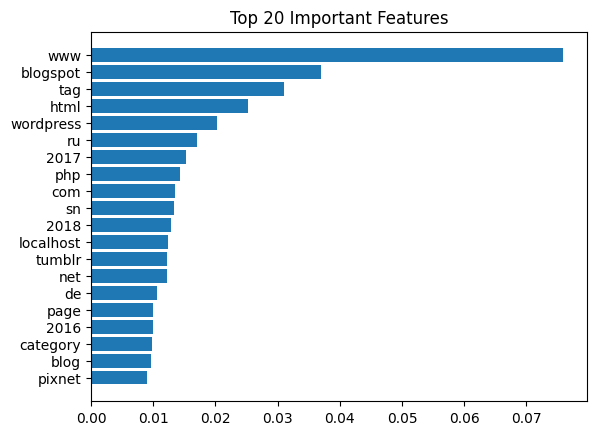

In [17]:
# Get feature importance
importances = model.feature_importances_

# Get feature names from TF-IDF
feature_names = vectorizer.get_feature_names_out()

# Create DataFrame
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
feat_imp = feat_imp.sort_values(by="Importance", ascending=False).head(20)

print(feat_imp)

# Plot
plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.show()

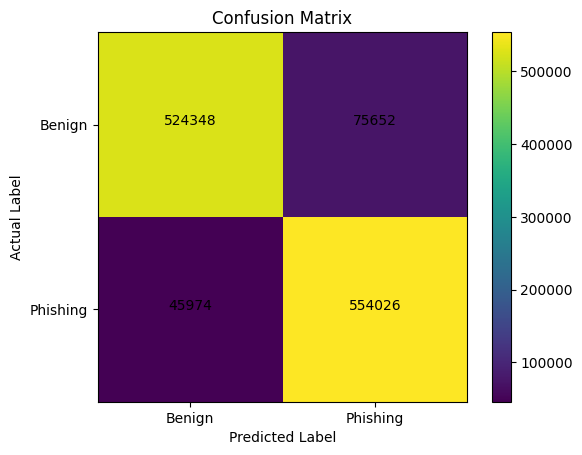

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Benign", "Phishing"])
plt.yticks(tick_marks, ["Benign", "Phishing"])

# Add numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center")

plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

In [20]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5)

print("Cross Validation Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

Cross Validation Scores: [0.8982375  0.89901429 0.90039107 0.89951429 0.89788929]
Mean CV Accuracy: 0.8990092857142858


In [21]:
feature_names = vectorizer.get_feature_names_out()
importances = model.feature_importances_

indices = np.argsort(importances)[::-1][:20]

print("Top 20 Important Features:\n")
for i in indices:
    print(feature_names[i], ":", round(importances[i], 6))

Top 20 Important Features:

www : 0.07597
blogspot : 0.036939
tag : 0.031059
html : 0.025302
wordpress : 0.020186
ru : 0.017
2017 : 0.015276
php : 0.014224
com : 0.013525
sn : 0.013286
2018 : 0.012791
localhost : 0.01238
tumblr : 0.012224
net : 0.012166
de : 0.010661
page : 0.010035
2016 : 0.009984
category : 0.009834
blog : 0.009561
pixnet : 0.009005


In [22]:
with open("model_report.txt", "w") as f:
    f.write("Accuracy:\n")
    f.write(str(accuracy_score(y_test, y_pred)))
    f.write("\n\nClassification Report:\n")
    f.write(classification_report(y_test, y_pred))